SVM Accuracy: 98.41%


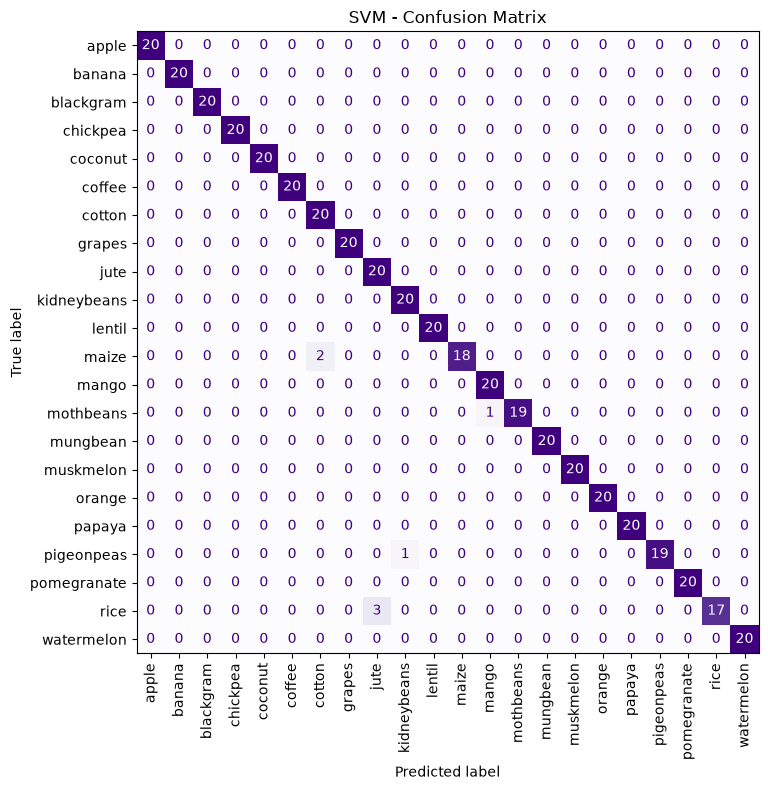

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

# 1. โหลดข้อมูล
df = pd.read_csv('crop_fertilizer_recommendation_dataset.csv')
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
target = 'label'

X = df[features]
y = df[target]

# 2. แบ่งข้อมูล
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. เทรนโมเดล
model = make_pipeline(StandardScaler(), SVC(kernel='rbf', C=1.0, random_state=42))
model.fit(X_train, y_train)

# 4. ประเมินผล
y_pred = model.predict(X_test)
print(f"SVM Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

# 5. พล็อตกราฟ Confusion Matrix
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap='Purples', colorbar=False)
plt.title('SVM - Confusion Matrix')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()